# Feature Importance — Top Peptides from Corrected Logistic Regression Pipeline

Extracts and visualises the most important peptides from the Logistic Regression L1 model saved by `modeling2.ipynb` (corrected pipeline, no data leakage).

**Prerequisites:** run `modeling2.ipynb` fully first so the model and peptide list are saved to `models/`.

A positive coefficient means higher peptide intensity pushes the model toward **Severe**.  
A negative coefficient means higher peptide intensity pushes the model toward **Non-severe**.  
The larger the absolute value, the more influence that peptide has on the prediction.

## Step 1 — Load the saved model and selected peptides

In [1]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

MODEL_DIR = Path("./models")

# Load the trained pipeline saved by modeling2.ipynb
pipeline          = joblib.load(MODEL_DIR / "modeling2_best_model.joblib")
best_model_name   = (MODEL_DIR / "modeling2_best_model_name.txt").read_text().strip()
selected_peptides = pd.read_csv(
    MODEL_DIR / "modeling2_selected_peptides.txt", header=None
)[0].tolist()

print(f"Model loaded  : {best_model_name}")
print(f"Peptides      : {len(selected_peptides)}")
print(f"Pipeline steps: {[s[0] for s in pipeline.steps]}")

Model loaded  : logistic_regression_l1
Peptides      : 200
Pipeline steps: ['imputer', 'scaler', 'model']


## Step 2 — Extract logistic regression coefficients

In [2]:
# Extract the fitted logistic regression step from the pipeline
lr = pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "peptide"        : selected_peptides,
    "coefficient"    : lr.coef_[0],
    "abs_coefficient": np.abs(lr.coef_[0]),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

# L1 regularisation drives unimportant peptide weights to exactly zero
n_nonzero = (feature_importance["coefficient"] != 0).sum()
print(f"Peptides with non-zero coefficient : {n_nonzero} / {len(feature_importance)}")
print(f"Peptides zeroed out by L1          : {len(feature_importance) - n_nonzero}")
print()
print("Top 20 peptides by absolute coefficient:")
print(feature_importance.head(20).to_string(index=False))

Peptides with non-zero coefficient : 6 / 200
Peptides zeroed out by L1          : 194

Top 20 peptides by absolute coefficient:
                                                                     peptide  coefficient  abs_coefficient
                                 S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K    -0.291871         0.291871
R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W    -0.240642         0.240642
                                 R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S     0.176614         0.176614
                                                    D.[304.207]EENLTQENQDR.G     0.163891         0.163891
                       R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A(K,304.207).Q    -0.142335         0.142335
       R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C,57.021)EE(K,304.207).S     0.040224         0.040224
                             R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G     0.000000         0.000000
                

## Step 3 — Bar chart of top 20 most important peptides

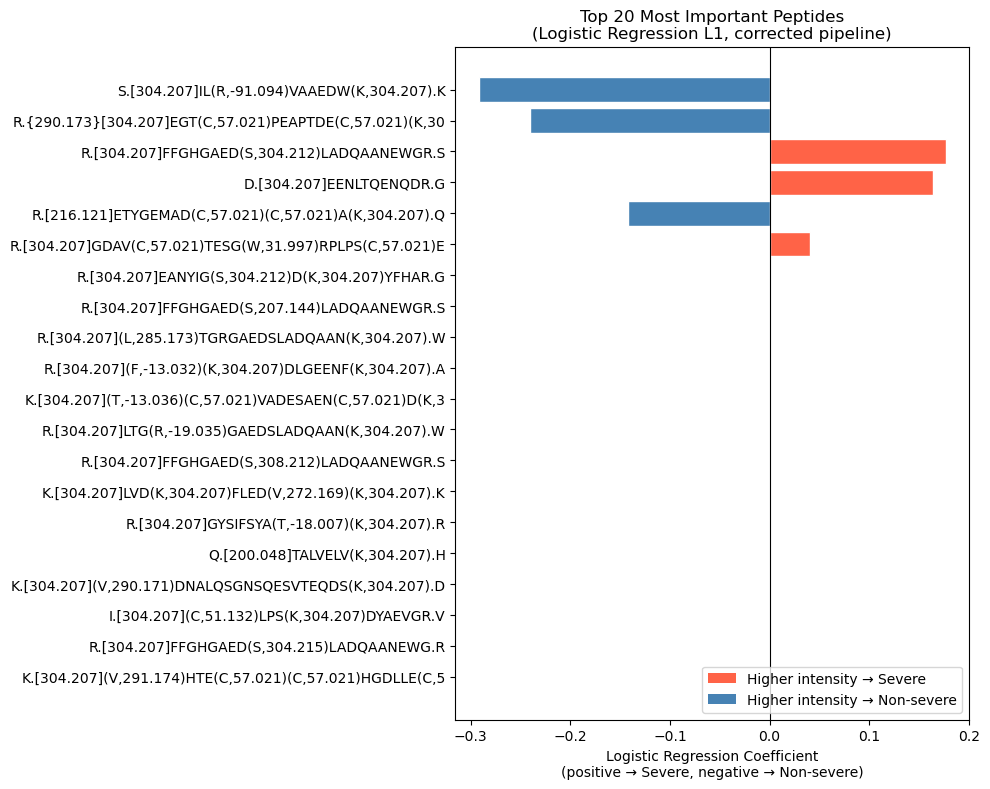

Chart saved as top20_peptide_importance.png


In [3]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20).copy()

# Shorten peptide names for readability on the chart
top20["label"] = top20["peptide"].str[:55]

colors = ["tomato" if c > 0 else "steelblue" for c in top20["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top20["label"], top20["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()  # most important peptide at the top

ax.set_xlabel("Logistic Regression Coefficient\n(positive → Severe, negative → Non-severe)")
ax.set_title("Top 20 Most Important Peptides\n(Logistic Regression L1, corrected pipeline)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    label="Higher intensity → Severe"),
    Patch(facecolor="steelblue", label="Higher intensity → Non-severe"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("top20_peptide_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as top20_peptide_importance.png")

## Step 4 — Deep-dive visualisations for the 6 non-zero peptides

In [4]:
# Load the full patient-level data and extract the 6 non-zero peptides
variants_processed = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)

top6_peptides = feature_importance[feature_importance["coefficient"] != 0]["peptide"].tolist()

severe_mask    = variants_processed["Condition"] == "Severe-COVID-19"
nonsevere_mask = variants_processed["Condition"] == "Non-severe-COVID-19"

print(f"Patients      : {len(variants_processed)} ({severe_mask.sum()} Severe, {nonsevere_mask.sum()} Non-severe)")
print(f"Top-6 peptides: {len(top6_peptides)}")
for p in top6_peptides:
    print(" ", p)

Patients      : 43 (18 Severe, 25 Non-severe)
Top-6 peptides: 6
  S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K
  R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W
  R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S
  D.[304.207]EENLTQENQDR.G
  R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A(K,304.207).Q
  R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C,57.021)EE(K,304.207).S


C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_46572\377471939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_46572\377471939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_46572\377471939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_46572\377471939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x

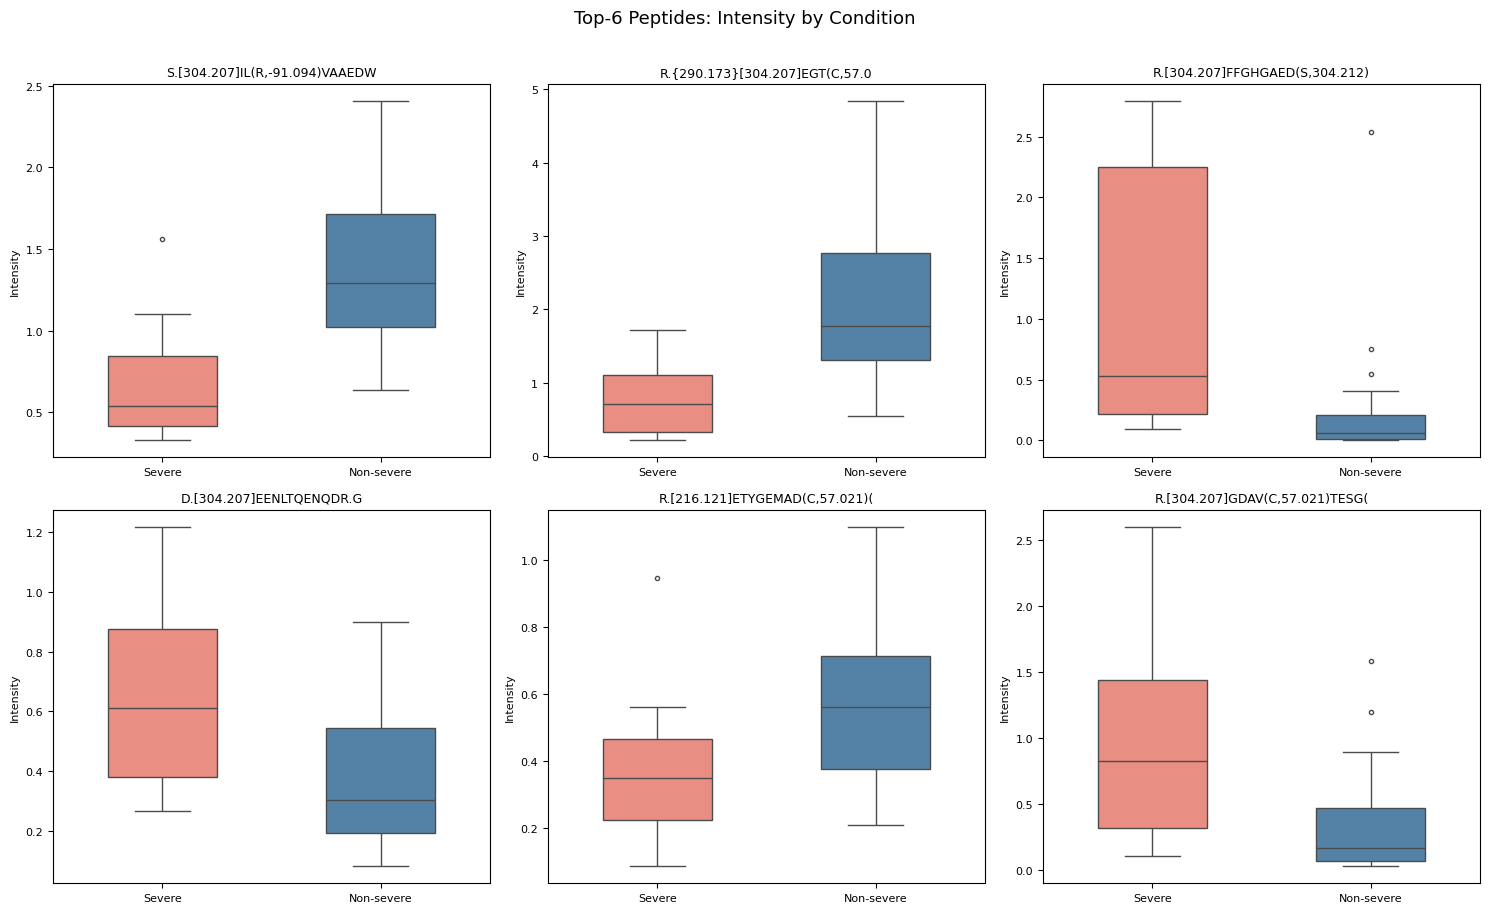

Saved: boxplots_top6.png


In [7]:
## Plot 1 — Box plots (2×3 grid)
import seaborn as sns

SEVERE_COLOR    = "salmon"
NONSEVERE_COLOR = "steelblue"

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, peptide in enumerate(top6_peptides):
    ax = axes[i]

    severe_vals    = variants_processed.loc[severe_mask,    peptide].dropna()
    nonsevere_vals = variants_processed.loc[nonsevere_mask, peptide].dropna()

    data = pd.DataFrame({
        "Intensity": pd.concat([severe_vals, nonsevere_vals]),
        "Condition": (["Severe"] * len(severe_vals) + ["Non-severe"] * len(nonsevere_vals)),
    })

    sns.boxplot(
        data=data, x="Condition", y="Intensity", ax=ax,
        palette={"Severe": SEVERE_COLOR, "Non-severe": NONSEVERE_COLOR},
        order=["Severe", "Non-severe"],
        width=0.5, flierprops=dict(marker="o", markersize=3),
    )

    ax.set_title(peptide[:30], fontsize=9, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("Intensity", fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle("Top-6 Peptides: Intensity by Condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("boxplots_top6.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: boxplots_top6.png")

In [8]:
## Plot 2 — Mann-Whitney U test table
from scipy.stats import mannwhitneyu

mw_rows = []
for peptide in top6_peptides:
    severe_vals    = variants_processed.loc[severe_mask,    peptide].dropna()
    nonsevere_vals = variants_processed.loc[nonsevere_mask, peptide].dropna()

    _, pval = mannwhitneyu(severe_vals, nonsevere_vals, alternative="two-sided")
    mw_rows.append({
        "Peptide (first 40 chars)": peptide[:40],
        "p-value":                  round(pval, 6),
        "p < 0.05":                 "Yes" if pval < 0.05 else "No",
    })

mw_table = pd.DataFrame(mw_rows)
print(mw_table.to_string(index=False))

mw_table.to_csv("mannwhitney_top6.csv", index=False)
print("\nSaved: mannwhitney_top6.csv")

                Peptide (first 40 chars)  p-value p < 0.05
S.[304.207]IL(R,-91.094)VAAEDW(K,304.207 0.000696      Yes
R.{290.173}[304.207]EGT(C,57.021)PEAPTDE 0.000042      Yes
R.[304.207]FFGHGAED(S,304.212)LADQAANEWG 0.000293      Yes
                D.[304.207]EENLTQENQDR.G 0.002442      Yes
R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A 0.010834      Yes
R.[304.207]GDAV(C,57.021)TESG(W,31.997)R 0.001107      Yes

Saved: mannwhitney_top6.csv


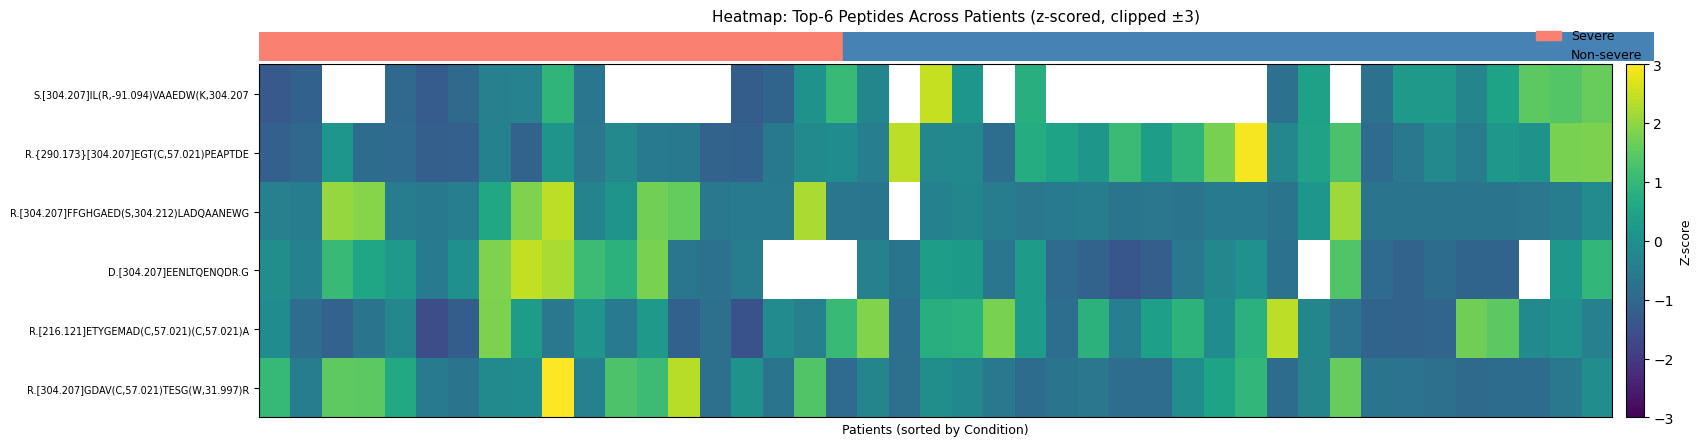

Saved: heatmap_top6.png


In [9]:
## Plot 3 — Heatmap (peptides × patients, z-scored, sorted by condition)
from scipy.stats import zscore

# Sort patients: Severe first, then Non-severe
sorted_idx = (
    variants_processed["Condition"]
    .map({"Severe-COVID-19": 0, "Non-severe-COVID-19": 1})
    .sort_values()
    .index
)
sorted_conditions = variants_processed.loc[sorted_idx, "Condition"]

# Extract the 6-peptide matrix, sort patients, z-score per peptide (column), clip to ±3
heatmap_data = variants_processed.loc[sorted_idx, top6_peptides].copy()
heatmap_zscored = heatmap_data.apply(
    lambda col: np.clip(zscore(col, nan_policy="omit"), -3, 3)
)

# Peptides as rows, patients as columns
heatmap_T = heatmap_zscored.T

# Build colour bar for Condition annotation
condition_colors = sorted_conditions.map(
    {"Severe-COVID-19": "salmon", "Non-severe-COVID-19": "steelblue"}
)

fig, axes = plt.subplots(
    2, 1, figsize=(18, 5),
    gridspec_kw={"height_ratios": [0.08, 1], "hspace": 0.02},
)

# ── Condition strip (top) ──────────────────────────────────────────────────
ax_strip = axes[0]
for j, (pat, color) in enumerate(condition_colors.items()):
    ax_strip.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
ax_strip.set_xlim(0, len(sorted_idx))
ax_strip.set_ylim(0, 1)
ax_strip.axis("off")

from matplotlib.patches import Patch
legend_patches = [
    Patch(color="salmon",    label="Severe"),
    Patch(color="steelblue", label="Non-severe"),
]
ax_strip.legend(handles=legend_patches, loc="upper right",
                bbox_to_anchor=(1, 1.5), frameon=False, fontsize=9)
ax_strip.set_title("Heatmap: Top-6 Peptides Across Patients (z-scored, clipped ±3)",
                   fontsize=11, pad=8)

# ── Heatmap ────────────────────────────────────────────────────────────────
ax_hm = axes[1]
im = ax_hm.imshow(
    heatmap_T.values, aspect="auto", cmap="viridis",
    vmin=-3, vmax=3, interpolation="none",
)

# White for NaN
ax_hm.set_facecolor("white")

ax_hm.set_yticks(range(len(top6_peptides)))
ax_hm.set_yticklabels([p[:40] for p in top6_peptides], fontsize=7)
ax_hm.set_xticks([])
ax_hm.set_xlabel("Patients (sorted by Condition)", fontsize=9)

cbar = fig.colorbar(im, ax=ax_hm, orientation="vertical", fraction=0.02, pad=0.01)
cbar.set_label("Z-score", fontsize=9)

plt.savefig("heatmap_top6.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap_top6.png")

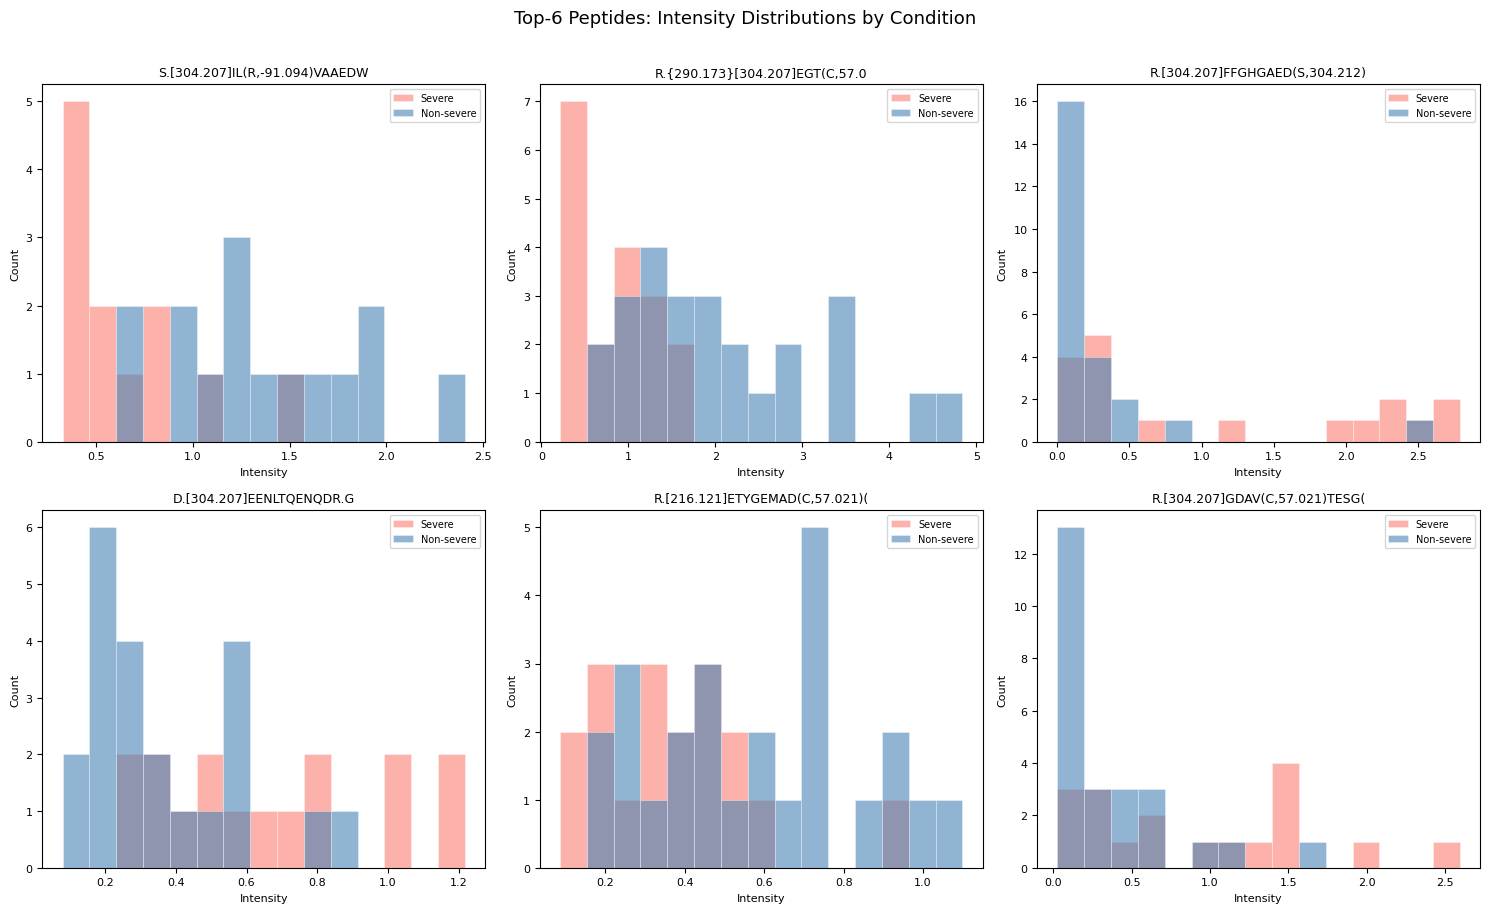

Saved: histograms_top6.png


In [10]:
## Plot 4 — Overlapping histograms (2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, peptide in enumerate(top6_peptides):
    ax = axes[i]

    severe_vals    = variants_processed.loc[severe_mask,    peptide].dropna()
    nonsevere_vals = variants_processed.loc[nonsevere_mask, peptide].dropna()

    # Shared bin edges across both groups for fair comparison
    combined = pd.concat([severe_vals, nonsevere_vals])
    bins = np.linspace(combined.min(), combined.max(), 16)

    ax.hist(severe_vals,    bins=bins, alpha=0.6, color=SEVERE_COLOR,
            label="Severe",     edgecolor="white", linewidth=0.4)
    ax.hist(nonsevere_vals, bins=bins, alpha=0.6, color=NONSEVERE_COLOR,
            label="Non-severe", edgecolor="white", linewidth=0.4)

    ax.set_title(peptide[:30], fontsize=9, pad=6)
    ax.set_xlabel("Intensity", fontsize=8)
    ax.set_ylabel("Count",     fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Top-6 Peptides: Intensity Distributions by Condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("histograms_top6.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: histograms_top6.png")